In [1]:
import numpy as np
import pandas as pd
import pandas_ta as ta
import matplotlib.pyplot as plt
from enum import Enum

# Scalping strategy.
Two SMA will be used to define the trend. And the bollinger bands indicator will be used to set the confirme the trading logic. If the price is below the lower bollinger band it may be a buy signal, like wise if the price is above the upper bollinger band it may be a sell signal.

The bollinger band and trend SMA will be combined to a trading signal. 

## Loade data

In [2]:
df_GOLD_Raw = pd.read_parquet(f"../Data/GOLD_1M.parquet")
df_baseline = pd.read_parquet(f"../Data/EURUSD_M1.parquet")
df_GOLD_Raw.head()

,open,high,low,close,volume
time,,,,,
2019-10-15 12:13:00,1492.87,1493.36,1492.77,1493.33,62
2019-10-15 12:14:00,1493.36,1493.47,1493.06,1493.07,47
2019-10-15 12:15:00,1493.09,1493.28,1492.97,1493.07,70
2019-10-15 12:16:00,1493.08,1493.35,1493.07,1493.35,28
2019-10-15 12:17:00,1493.30,1493.36,1493.14,1493.28,38


In [3]:
def get_resampled(df, high_freq='4h'):
    volume_col = 'tick_volume' if 'tick_volume' in df.columns else 'volume'

    df_high_sample_rate = df.resample(high_freq).agg(
        open=('open', 'first'),
        high=('high', 'max'),
        low=('low', 'min'),
        close=('close', 'last'),
        volume=(volume_col, 'sum'),
        High_time=('high', lambda x: x.idxmax() if len(x) > 0 else None),
        Low_time=('low', lambda x: x.idxmin() if len(x) > 0 else None)
    )

    df_high_sample_rate = df_high_sample_rate.dropna()

    return df_high_sample_rate

In [4]:
df_GOLD = get_resampled(df_GOLD_Raw, high_freq="5min")
df_baseline = get_resampled(df_baseline, high_freq="5min")

## Build strategy

In [5]:
class TimeFrame(Enum):
  DAILY = 252
  MIN_1 = 252 * 24 * 60
  MIN_5 = 252 * 24 * 12
  MIN_10 = 252 * 24 * 6
  HOUR_1 = 252 * 24
  HOUR_6 = 252 * 4

selected_timeframe = TimeFrame.MIN_5

def drawdown_function(returns):

  # Build an equity curve from periodic returns, then compute peak-to-trough drawdown
  equity_curve = (1 + returns.dropna()).cumprod()
  running_max = equity_curve.cummax()
  drawdown = equity_curve / running_max - 1
  return drawdown

def BackTest(strategy_data, baseline_data, annualiazed_scalar=selected_timeframe):

  # Accept either enum or numeric annualization scalar
  annualized_scalar = annualiazed_scalar.value if isinstance(annualiazed_scalar, Enum) else float(annualiazed_scalar)

  # Ensure a clean strategy return series
  serie = strategy_data.copy()
  if isinstance(serie, pd.DataFrame):
    if "return" in serie.columns:
      serie = serie["return"]
    else:
      serie = serie.iloc[:, 0]
  serie = serie.rename("return").dropna()
  if not serie.index.is_unique:
    serie = serie[~serie.index.duplicated(keep="first")]

  # Build benchmark return series from close prices
  if isinstance(baseline_data, pd.DataFrame):
    if "close" in baseline_data.columns:
      baseline_price = baseline_data["close"]
    else:
      baseline_price = baseline_data.iloc[:, 0]
  else:
    baseline_price = baseline_data

  baseline = baseline_price.pct_change(1).rename("EURUSD").dropna()
  if not baseline.index.is_unique:
    baseline = baseline[~baseline.index.duplicated(keep="first")]

  # Align by timestamps to avoid mixing unrelated bars
  val = pd.concat((serie, baseline), axis=1, join="inner").dropna()
  if val.empty:
    raise ValueError("No overlapping timestamps between strategy and benchmark after alignment.")

  # Final compounded returns
  final_return_portfolio = (1 + val["return"]).prod() - 1
  final_return_benchmark = (1 + val["EURUSD"]).prod() - 1

  # Compute drawdown on aligned strategy returns
  drawdown = drawdown_function(val["return"]) * 100

  # Compute max drawdown
  max_drawdown = -np.min(drawdown)

  # Put a subplots
  fig, (cum, dra) = plt.subplots(1, 2, figsize=(20, 6))

  # Put a Suptitle
  fig.suptitle("Backtesting", size=20)

  # Returns equity curves
  cum.plot(((1 + val["return"]).cumprod() - 1) * 100, color="#39B3C7")

  # EURUSD equity curve
  cum.plot(((1 + val["EURUSD"]).cumprod() - 1) * 100, color="#B85A0F")

  # Put a legend
  cum.legend(["Portfolio", "EURUSD"])

  # Set individual title
  cum.set_title("Cumulative Return", size=13)

  cum.set_ylabel("Cumulative Return %", size=11)

  # Put the drawdown
  dra.fill_between(drawdown.index, 0, drawdown, color="#C73954", alpha=0.65)

  # Set individual title
  dra.set_title("Drawdown", size=13)

  dra.set_ylabel("drawdown in %", size=11)

  # Plot the graph
  plt.show()

  # Compute the sortino
  downside_std = val.loc[val["return"] < 0, "return"].std()
  sortino = np.nan if (pd.isna(downside_std) or downside_std == 0) else np.sqrt(annualized_scalar) * val["return"].mean() / downside_std

  # Compute the beta
  benchmark_var = np.var(val["EURUSD"].values)
  beta = np.nan if benchmark_var == 0 else np.cov(val[["return", "EURUSD"]].values, rowvar=False)[0][1] / benchmark_var

  # Compute the alpha
  alpha = np.nan if pd.isna(beta) else annualized_scalar * (val["return"].mean() - beta * val["EURUSD"].mean())

  # Print the statistics
  print(f"Final Return Portfolio: {final_return_portfolio:.2%}")
  print(f"Final Return EURUSD: {final_return_benchmark:.2%}")
  print(f"Sortino: {np.round(sortino,3)}")
  print(f"Beta: {np.round(beta,3)}")
  print(f"Alpha: {np.round(alpha*100,3)} %")
  print(f"MaxDrawdown: {np.round(max_drawdown,3)} %")

  return {
    "final_return_portfolio": final_return_portfolio,
    "final_return_benchmark": final_return_benchmark,
    "sortino": sortino,
    "beta": beta,
    "alpha": alpha,
    "max_drawdown": max_drawdown,
  }

def Scalping_strategy(df=df_GOLD_Raw, SMA_Fast = 30, SMA_Slow = 60, bb_length=15, bb_std=2, transaction_cost=0.0):
  
  df = df.copy()

  # Create fast and slow SMAs
  df["EMA_fast"] = df["close"].ewm(span=SMA_Fast, adjust=False).mean()
  df["EMA_slow"] = df["close"].ewm(span=SMA_Slow, adjust=False).mean()

  bb = df.ta.bbands(length= bb_length, std=bb_std)

  bb.columns = ["bb_lower", "bb_mid", "bb_upper", "bb_width", "bb_percent"]

  df = pd.concat([df, bb], axis=1)

  backcandles = 7

  cond_below = df["EMA_fast"] < df["EMA_slow"]
  cond_above = df["EMA_fast"] > df["EMA_slow"]

  # Rolling checks
  all_below = cond_below.rolling(window=backcandles).sum() == backcandles
  all_above = cond_above.rolling(window=backcandles).sum() == backcandles

  # Build signal
  df["EMASignal"] = 0
  df.loc[all_below, "EMASignal"] = 1
  df.loc[all_above, "EMASignal"] = 2

  df['position'] = np.nan
  df.loc[(df['EMASignal'] == 1) & (df['bb_lower']<df['close']), 'position'] = 1
  df.loc[(df['EMASignal'] == 2) & (df['bb_upper']>df['close']), 'position'] = -1
  df['position'] = df['position'].ffill().fillna(0)


  # Keep previous position between signals, then flat before first signal
  df["position"] = df["position"].ffill().fillna(0)

  df["pct"] = df["close"].pct_change(1)

  # Apply transaction cost only when a position change occurs
  turnover = df["position"].diff().abs().fillna(0).clip(upper=1)
  df["return"] = df["pct"] * df["position"].shift(1) - transaction_cost * turnover

  # Keep only valid strategy returns; avoids plotting an all-NaN series
  ret = df["return"].dropna()
  if ret.empty:
    raise ValueError("No valid returns. Download more history or reduce SMA windows.")

  return ret

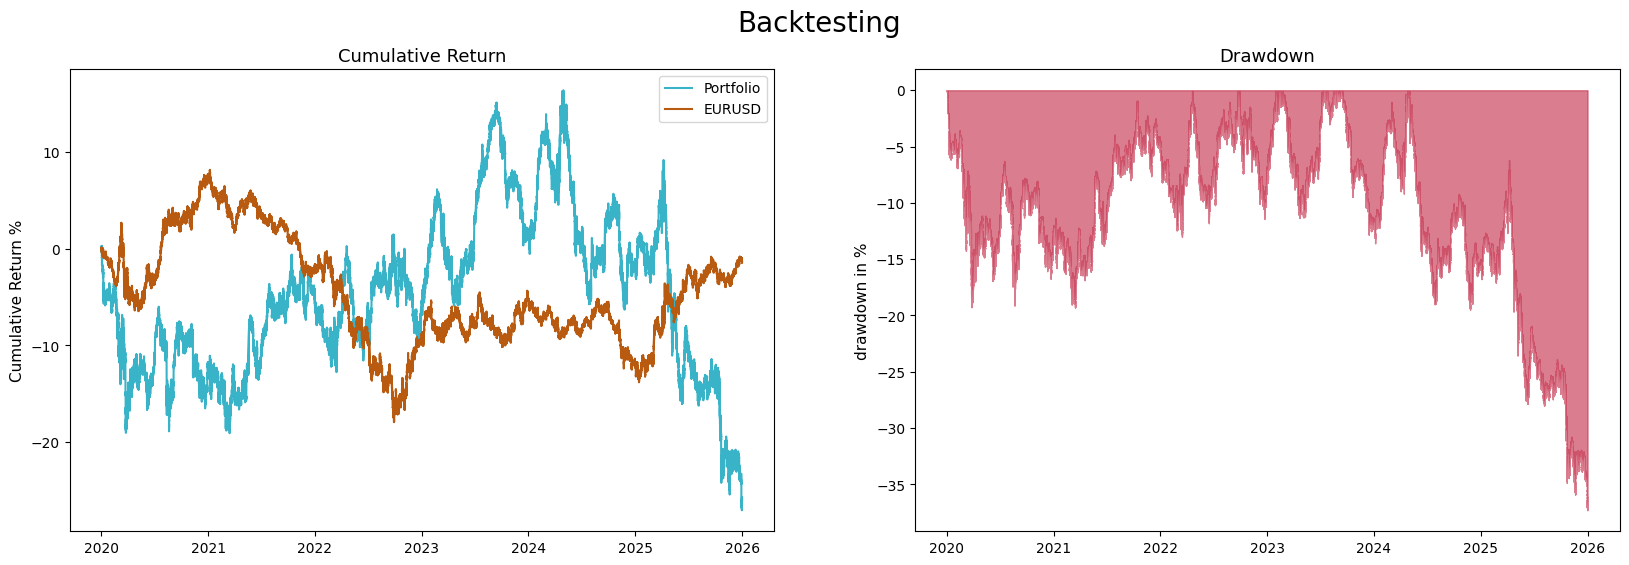

Final Return Portfolio: -25.84%
Final Return EURUSD: -1.29%
Sortino: -0.311
Beta: -0.001
Alpha: -3.896 %
MaxDrawdown: 37.306 %


In [6]:
df_GOLD = get_resampled(df_GOLD_Raw, high_freq="5min")
dfc = Scalping_strategy(df_GOLD, SMA_Fast = 30, SMA_Slow = 60, bb_length=15, bb_std=2, transaction_cost=0.00001)
metrics = BackTest(dfc, df_baseline, selected_timeframe)

Starting parameter search: 400 total combinations
Processed 50/400 combinations
Processed 100/400 combinations
Processed 150/400 combinations
Processed 200/400 combinations
Processed 250/400 combinations
Processed 300/400 combinations
Processed 350/400 combinations
Processed 400/400 combinations

Top 10 parameter sets (by composite score):
 SMA_Fast  SMA_Slow  bb_length  bb_std     score  final_return_portfolio   sortino     alpha  max_drawdown
       10        60         15     1.5 -0.226920               -0.141728 -0.107695 -0.013526     37.210959
       10        60         15     2.0 -0.226920               -0.141728 -0.107695 -0.013526     37.210959
       10        60         15     2.5 -0.226920               -0.141728 -0.107695 -0.013526     37.210959
       10        60         15     3.0 -0.226920               -0.141728 -0.107695 -0.013526     37.210959
       10        60         10     1.5 -0.258914               -0.168290 -0.151243 -0.018999     37.749922
       10       

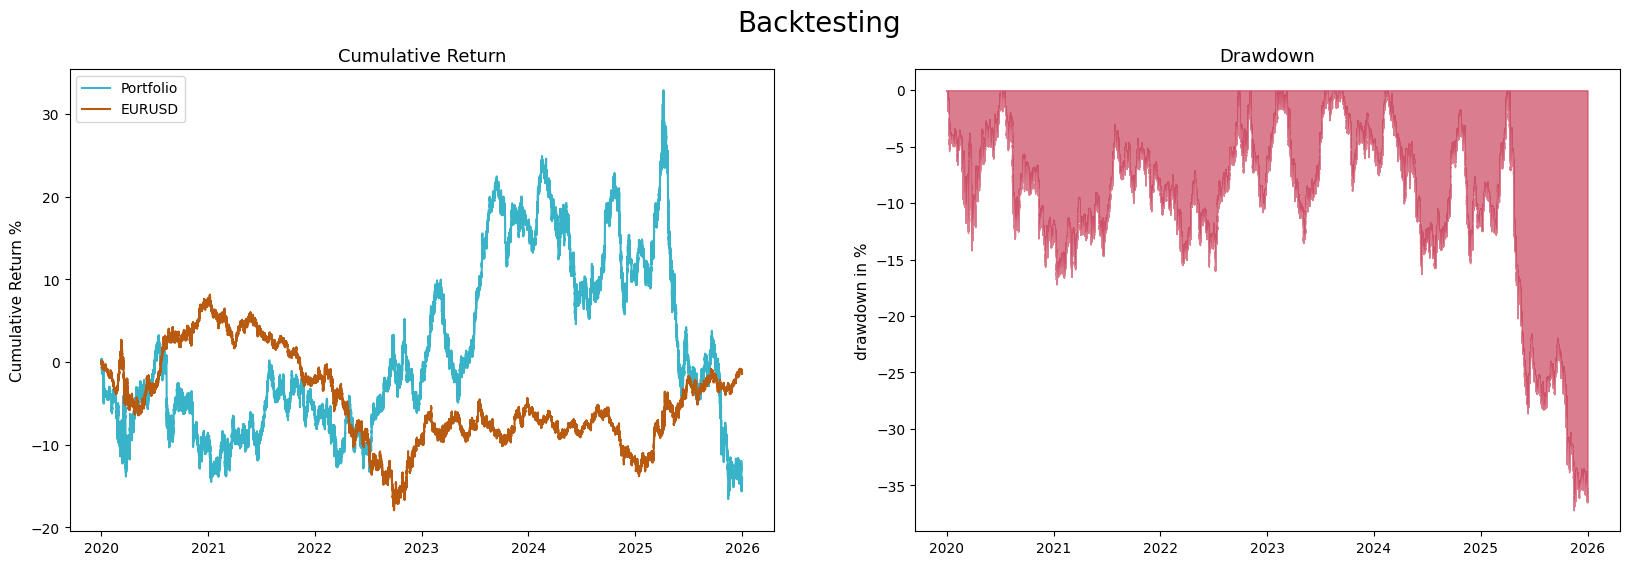

Final Return Portfolio: -14.17%
Final Return EURUSD: -1.29%
Sortino: -0.108
Beta: -0.001
Alpha: -1.353 %
MaxDrawdown: 37.211 %


In [7]:
# Parameter search for Scalping_strategy
from itertools import product
import numpy as np
import pandas as pd


def evaluate_scalping_no_plot(strategy_returns, baseline_data, annualized_scalar=selected_timeframe):
    """Compute the same core metrics as BackTest without generating charts."""
    annualized = annualized_scalar.value if isinstance(annualized_scalar, Enum) else float(annualized_scalar)

    serie = strategy_returns.copy()
    if isinstance(serie, pd.DataFrame):
        if "return" in serie.columns:
            serie = serie["return"]
        else:
            serie = serie.iloc[:, 0]
    serie = serie.rename("return").dropna()
    if not serie.index.is_unique:
        serie = serie[~serie.index.duplicated(keep="first")]

    if isinstance(baseline_data, pd.DataFrame):
        baseline_price = baseline_data["close"] if "close" in baseline_data.columns else baseline_data.iloc[:, 0]
    else:
        baseline_price = baseline_data

    baseline = baseline_price.pct_change(1).rename("EURUSD").dropna()
    if not baseline.index.is_unique:
        baseline = baseline[~baseline.index.duplicated(keep="first")]

    val = pd.concat((serie, baseline), axis=1, join="inner").dropna()
    if val.empty:
        return None

    final_return_portfolio = (1 + val["return"]).prod() - 1
    final_return_benchmark = (1 + val["EURUSD"]).prod() - 1

    drawdown = drawdown_function(val["return"]) * 100
    max_drawdown = -np.min(drawdown)

    downside_std = val.loc[val["return"] < 0, "return"].std()
    sortino = np.nan if (pd.isna(downside_std) or downside_std == 0) else np.sqrt(annualized) * val["return"].mean() / downside_std

    benchmark_var = np.var(val["EURUSD"].values)
    beta = np.nan if benchmark_var == 0 else np.cov(val[["return", "EURUSD"]].values, rowvar=False)[0][1] / benchmark_var
    alpha = np.nan if pd.isna(beta) else annualized * (val["return"].mean() - beta * val["EURUSD"].mean())

    return {
        "final_return_portfolio": final_return_portfolio,
        "final_return_benchmark": final_return_benchmark,
        "sortino": sortino,
        "beta": beta,
        "alpha": alpha,
        "max_drawdown": max_drawdown,
    }


# Build search grid (compact to keep runtime reasonable)
param_grid = list(
    product(
        [10, 15, 20, 30, 40],      # SMA_Fast
        [40, 60, 80, 100, 120],    # SMA_Slow
        [10, 15, 20, 25],          # bb_length
        [1.5, 2.0, 2.5, 3.0],      # bb_std
    )
)

results = []
print(f"Starting parameter search: {len(param_grid)} total combinations")

for i, (sma_fast, sma_slow, bb_len, bb_std) in enumerate(param_grid, start=1):
    if sma_fast >= sma_slow:
        continue

    try:
        ret = Scalping_strategy(
            df=df_GOLD,
            SMA_Fast=sma_fast,
            SMA_Slow=sma_slow,
            bb_length=bb_len,
            bb_std=bb_std,
            transaction_cost=0.00001,
        )

        m = evaluate_scalping_no_plot(ret, df_baseline, selected_timeframe)
        if m is None:
            continue

        # Composite score favors return and sortino, penalizes drawdown.
        score = (
            1.0 * m["final_return_portfolio"]
            + 0.10 * (0.0 if pd.isna(m["sortino"]) else m["sortino"])
            - 0.002 * m["max_drawdown"]
        )

        results.append(
            {
                "SMA_Fast": sma_fast,
                "SMA_Slow": sma_slow,
                "bb_length": bb_len,
                "bb_std": bb_std,
                "score": score,
                **m,
            }
        )

        if i % 50 == 0:
            print(f"Processed {i}/{len(param_grid)} combinations")

    except Exception:
        continue

if not results:
    print("No valid parameter combinations found.")
else:
    results_df = pd.DataFrame(results).sort_values("score", ascending=False).reset_index(drop=True)

    show_cols = [
        "SMA_Fast", "SMA_Slow", "bb_length", "bb_std",
        "score", "final_return_portfolio", "sortino", "alpha", "max_drawdown"
    ]

    print("\nTop 10 parameter sets (by composite score):")
    print(results_df[show_cols].head(10).to_string(index=False))

    best_params = results_df.iloc[0]
    print("\nBest parameters:")
    print(
        f"SMA_Fast={int(best_params['SMA_Fast'])}, "
        f"SMA_Slow={int(best_params['SMA_Slow'])}, "
        f"bb_length={int(best_params['bb_length'])}, "
        f"bb_std={float(best_params['bb_std'])}"
    )

    print("\nRunning full BackTest on best parameters...\n")
    dfc_best = Scalping_strategy(
        df=df_GOLD,
        SMA_Fast=int(best_params["SMA_Fast"]),
        SMA_Slow=int(best_params["SMA_Slow"]),
        bb_length=int(best_params["bb_length"]),
        bb_std=float(best_params["bb_std"]),
        transaction_cost=0.00001,
    )
    best_metrics = BackTest(dfc_best, df_baseline, selected_timeframe)

## Scalping_strategy_v2 with optimization
This version uses explicit trade management (entry, stop, take-profit, time stop) and then runs a parameter search to find robust settings.

In [ ]:
# Improved scalping strategy with explicit exits and optimized parameters
from itertools import product


def Scalping_strategy_v2(
    df=df_GOLD_Raw,
    SMA_Fast=20,
    SMA_Slow=80,
    bb_length=20,
    bb_std=2.0,
    rsi_length=14,
    rsi_long_th=35,
    rsi_short_th=65,
    atr_length=14,
    atr_stop_mult=1.2,
    atr_tp_mult=0.8,
    max_hold_bars=10,
    min_bb_width=0.0008,
    transaction_cost=0.0,
    long_only=False,
):
    data = df.copy()

    # Trend filter
    data["EMA_fast"] = data["close"].ewm(span=SMA_Fast, adjust=False).mean()
    data["EMA_slow"] = data["close"].ewm(span=SMA_Slow, adjust=False).mean()

    # Bollinger bands and width
    bb = data.ta.bbands(length=bb_length, std=bb_std)
    bb.columns = ["bb_lower", "bb_mid", "bb_upper", "bb_width", "bb_percent"]
    data = pd.concat([data, bb], axis=1)

    # RSI filter
    data["rsi"] = ta.rsi(data["close"], length=rsi_length)

    # ATR for stop and take-profit distances
    atr_df = data.ta.atr(length=atr_length)
    if isinstance(atr_df, pd.DataFrame):
        data["atr"] = atr_df.iloc[:, 0]
    else:
        data["atr"] = atr_df

    strategy_ret = np.zeros(len(data), dtype=float)

    current_pos = 0.0
    entry_price = np.nan
    bars_in_trade = 0

    for i in range(1, len(data)):
        px = data["close"].iloc[i]
        px_prev = data["close"].iloc[i - 1]
        atr = data["atr"].iloc[i]
        bb_width = data["bb_width"].iloc[i]
        ema_fast = data["EMA_fast"].iloc[i]
        ema_slow = data["EMA_slow"].iloc[i]
        bb_lower = data["bb_lower"].iloc[i]
        bb_mid = data["bb_mid"].iloc[i]
        bb_upper = data["bb_upper"].iloc[i]
        rsi = data["rsi"].iloc[i]

        if np.isnan(atr) or np.isnan(bb_width) or np.isnan(rsi) or np.isnan(bb_mid):
            continue

        # Mark-to-market while in trade
        if current_pos != 0.0:
            strategy_ret[i] = current_pos * (px / px_prev - 1.0)
            bars_in_trade += 1

            if current_pos > 0:
                stop_price = entry_price - atr_stop_mult * atr
                tp_price = entry_price + atr_tp_mult * atr
                exit_cond = (px <= stop_price) or (px >= tp_price) or (px >= bb_mid) or (bars_in_trade >= max_hold_bars)
            else:
                stop_price = entry_price + atr_stop_mult * atr
                tp_price = entry_price - atr_tp_mult * atr
                exit_cond = (px >= stop_price) or (px <= tp_price) or (px <= bb_mid) or (bars_in_trade >= max_hold_bars)

            if exit_cond:
                strategy_ret[i] -= abs(current_pos) * transaction_cost
                current_pos = 0.0
                entry_price = np.nan
                bars_in_trade = 0

        # Entry logic when flat
        if current_pos == 0.0 and bb_width >= min_bb_width:
            long_signal = (ema_fast > ema_slow) and (px <= bb_lower) and (rsi <= rsi_long_th)
            short_signal = (ema_fast < ema_slow) and (px >= bb_upper) and (rsi >= rsi_short_th)

            if long_signal:
                current_pos = 1.0
                entry_price = px
                bars_in_trade = 0
                strategy_ret[i] -= transaction_cost
            elif (not long_only) and short_signal:
                current_pos = -1.0
                entry_price = px
                bars_in_trade = 0
                strategy_ret[i] -= transaction_cost

    ret = pd.Series(strategy_ret, index=data.index, name="return").dropna()
    if ret.empty:
        raise ValueError("No valid returns in Scalping_strategy_v2.")
    return ret


# Parameter optimization for v2 (compact grid for practical runtime)
v2_grid = list(
    product(
        [15, 20, 30],             # SMA_Fast
        [60, 80, 100],            # SMA_Slow
        [15, 20],                 # bb_length
        [1.8, 2.0],               # bb_std
        [35],                     # rsi_long_th
        [65],                     # rsi_short_th
        [1.0, 1.2],               # atr_stop_mult
        [0.6, 0.8],               # atr_tp_mult
        [8, 10],                  # max_hold_bars
        [0.0008, 0.0010],         # min_bb_width
    )
)

v2_results = []
print(f"Starting Scalping_strategy_v2 optimization with {len(v2_grid)} combinations")

for idx, (
    sma_fast,
    sma_slow,
    bb_len,
    bb_std,
    rsi_l,
    rsi_s,
    stop_mult,
    tp_mult,
    hold_bars,
    min_width,
) in enumerate(v2_grid, start=1):
    if sma_fast >= sma_slow:
        continue

    try:
        ret_v2 = Scalping_strategy_v2(
            df=df_GOLD,
            SMA_Fast=sma_fast,
            SMA_Slow=sma_slow,
            bb_length=bb_len,
            bb_std=bb_std,
            rsi_length=14,
            rsi_long_th=rsi_l,
            rsi_short_th=rsi_s,
            atr_length=14,
            atr_stop_mult=stop_mult,
            atr_tp_mult=tp_mult,
            max_hold_bars=hold_bars,
            min_bb_width=min_width,
            transaction_cost=0.00001,
            long_only=False,
        )

        metrics_v2 = evaluate_scalping_no_plot(ret_v2, df_baseline, selected_timeframe)
        if metrics_v2 is None:
            continue

        score_v2 = (
            1.0 * metrics_v2["final_return_portfolio"]
            + 0.12 * (0.0 if pd.isna(metrics_v2["sortino"]) else metrics_v2["sortino"])
            - 0.002 * metrics_v2["max_drawdown"]
        )

        v2_results.append(
            {
                "SMA_Fast": sma_fast,
                "SMA_Slow": sma_slow,
                "bb_length": bb_len,
                "bb_std": bb_std,
                "rsi_long_th": rsi_l,
                "rsi_short_th": rsi_s,
                "atr_stop_mult": stop_mult,
                "atr_tp_mult": tp_mult,
                "max_hold_bars": hold_bars,
                "min_bb_width": min_width,
                "score": score_v2,
                **metrics_v2,
            }
        )

        if idx % 100 == 0:
            print(f"Processed {idx}/{len(v2_grid)} combinations")

    except Exception:
        continue

if not v2_results:
    print("No valid v2 combinations were found.")
else:
    v2_results_df = pd.DataFrame(v2_results).sort_values("score", ascending=False).reset_index(drop=True)

    v2_cols = [
        "SMA_Fast", "SMA_Slow", "bb_length", "bb_std", "rsi_long_th", "rsi_short_th",
        "atr_stop_mult", "atr_tp_mult", "max_hold_bars", "min_bb_width",
        "score", "final_return_portfolio", "sortino", "alpha", "max_drawdown"
    ]

    print("\nTop 10 v2 parameter sets:")
    print(v2_results_df[v2_cols].head(10).to_string(index=False))

    v2_best_params = v2_results_df.iloc[0]
    print("\nBest v2 parameters:")
    print(v2_best_params[v2_cols].to_string())

    print("\nRunning full BackTest for best v2...\n")
    dfc_v2_best = Scalping_strategy_v2(
        df=df_GOLD,
        SMA_Fast=int(v2_best_params["SMA_Fast"]),
        SMA_Slow=int(v2_best_params["SMA_Slow"]),
        bb_length=int(v2_best_params["bb_length"]),
        bb_std=float(v2_best_params["bb_std"]),
        rsi_length=14,
        rsi_long_th=float(v2_best_params["rsi_long_th"]),
        rsi_short_th=float(v2_best_params["rsi_short_th"]),
        atr_length=14,
        atr_stop_mult=float(v2_best_params["atr_stop_mult"]),
        atr_tp_mult=float(v2_best_params["atr_tp_mult"]),
        max_hold_bars=int(v2_best_params["max_hold_bars"]),
        min_bb_width=float(v2_best_params["min_bb_width"]),
        transaction_cost=0.00001,
        long_only=False,
    )
    v2_best_metrics = BackTest(dfc_v2_best, df_baseline, selected_timeframe)

Starting Scalping_strategy_v2 optimization with 17496 combinations


In [ ]:
# Scalping_strategy_v2 compact optimization (self-contained)
from itertools import product


def evaluate_scalping_no_plot_v2(strategy_returns, baseline_data, annualized_scalar=selected_timeframe):
    annualized = annualized_scalar.value if isinstance(annualized_scalar, Enum) else float(annualized_scalar)

    serie = strategy_returns.rename("return").dropna()
    if not serie.index.is_unique:
        serie = serie[~serie.index.duplicated(keep="first")]

    baseline_price = baseline_data["close"] if "close" in baseline_data.columns else baseline_data.iloc[:, 0]
    baseline = baseline_price.pct_change(1).rename("EURUSD").dropna()
    if not baseline.index.is_unique:
        baseline = baseline[~baseline.index.duplicated(keep="first")]

    val = pd.concat((serie, baseline), axis=1, join="inner").dropna()
    if val.empty:
        return None

    final_return_portfolio = (1 + val["return"]).prod() - 1
    drawdown = drawdown_function(val["return"]) * 100
    max_drawdown = -np.min(drawdown)

    downside_std = val.loc[val["return"] < 0, "return"].std()
    sortino = np.nan if (pd.isna(downside_std) or downside_std == 0) else np.sqrt(annualized) * val["return"].mean() / downside_std

    benchmark_var = np.var(val["EURUSD"].values)
    beta = np.nan if benchmark_var == 0 else np.cov(val[["return", "EURUSD"]].values, rowvar=False)[0][1] / benchmark_var
    alpha = np.nan if pd.isna(beta) else annualized * (val["return"].mean() - beta * val["EURUSD"].mean())

    return {
        "final_return_portfolio": final_return_portfolio,
        "sortino": sortino,
        "alpha": alpha,
        "max_drawdown": max_drawdown,
    }


def Scalping_strategy_v2(
    df=df_GOLD_Raw,
    SMA_Fast=20,
    SMA_Slow=80,
    bb_length=20,
    bb_std=2.0,
    rsi_length=14,
    rsi_long_th=35,
    rsi_short_th=65,
    atr_length=14,
    atr_stop_mult=1.2,
    atr_tp_mult=0.8,
    max_hold_bars=10,
    min_bb_width=0.0008,
    transaction_cost=0.0,
    long_only=False,
):
    data = df.copy()

    data["EMA_fast"] = data["close"].ewm(span=SMA_Fast, adjust=False).mean()
    data["EMA_slow"] = data["close"].ewm(span=SMA_Slow, adjust=False).mean()

    bb = data.ta.bbands(length=bb_length, std=bb_std)
    bb.columns = ["bb_lower", "bb_mid", "bb_upper", "bb_width", "bb_percent"]
    data = pd.concat([data, bb], axis=1)

    data["rsi"] = ta.rsi(data["close"], length=rsi_length)
    data["atr"] = ta.atr(data["high"], data["low"], data["close"], length=atr_length)

    strategy_ret = np.zeros(len(data), dtype=float)
    current_pos = 0.0
    entry_price = np.nan
    bars_in_trade = 0

    for i in range(1, len(data)):
        px = data["close"].iloc[i]
        px_prev = data["close"].iloc[i - 1]
        atr = data["atr"].iloc[i]
        bb_width = data["bb_width"].iloc[i]
        ema_fast = data["EMA_fast"].iloc[i]
        ema_slow = data["EMA_slow"].iloc[i]
        bb_lower = data["bb_lower"].iloc[i]
        bb_mid = data["bb_mid"].iloc[i]
        bb_upper = data["bb_upper"].iloc[i]
        rsi = data["rsi"].iloc[i]

        if np.isnan(atr) or np.isnan(bb_width) or np.isnan(rsi) or np.isnan(bb_mid):
            continue

        if current_pos != 0.0:
            strategy_ret[i] = current_pos * (px / px_prev - 1.0)
            bars_in_trade += 1

            if current_pos > 0:
                stop_price = entry_price - atr_stop_mult * atr
                tp_price = entry_price + atr_tp_mult * atr
                exit_cond = (px <= stop_price) or (px >= tp_price) or (px >= bb_mid) or (bars_in_trade >= max_hold_bars)
            else:
                stop_price = entry_price + atr_stop_mult * atr
                tp_price = entry_price - atr_tp_mult * atr
                exit_cond = (px >= stop_price) or (px <= tp_price) or (px <= bb_mid) or (bars_in_trade >= max_hold_bars)

            if exit_cond:
                strategy_ret[i] -= abs(current_pos) * transaction_cost
                current_pos = 0.0
                entry_price = np.nan
                bars_in_trade = 0

        if current_pos == 0.0 and bb_width >= min_bb_width:
            long_signal = (ema_fast > ema_slow) and (px <= bb_lower) and (rsi <= rsi_long_th)
            short_signal = (ema_fast < ema_slow) and (px >= bb_upper) and (rsi >= rsi_short_th)

            if long_signal:
                current_pos = 1.0
                entry_price = px
                bars_in_trade = 0
                strategy_ret[i] -= transaction_cost
            elif (not long_only) and short_signal:
                current_pos = -1.0
                entry_price = px
                bars_in_trade = 0
                strategy_ret[i] -= transaction_cost

    ret = pd.Series(strategy_ret, index=data.index, name="return").dropna()
    if ret.empty:
        raise ValueError("No valid returns in Scalping_strategy_v2.")
    return ret


v2_grid = list(
    product(
        [15, 20, 30],     # SMA_Fast
        [60, 80, 100],    # SMA_Slow
        [15, 20],         # bb_length
        [1.8, 2.0],       # bb_std
        [1.0, 1.2],       # atr_stop_mult
        [0.6, 0.8],       # atr_tp_mult
        [8, 10],          # max_hold_bars
    )
)

v2_results = []
print(f"Starting compact v2 optimization with {len(v2_grid)} combinations")

for idx, (sma_fast, sma_slow, bb_len, bb_std, stop_mult, tp_mult, hold_bars) in enumerate(v2_grid, start=1):
    if sma_fast >= sma_slow:
        continue

    try:
        ret_v2 = Scalping_strategy_v2(
            df=df_GOLD,
            SMA_Fast=sma_fast,
            SMA_Slow=sma_slow,
            bb_length=bb_len,
            bb_std=bb_std,
            rsi_length=14,
            rsi_long_th=35,
            rsi_short_th=65,
            atr_length=14,
            atr_stop_mult=stop_mult,
            atr_tp_mult=tp_mult,
            max_hold_bars=hold_bars,
            min_bb_width=0.0008,
            transaction_cost=0.00001,
            long_only=False,
        )

        metrics_v2 = evaluate_scalping_no_plot_v2(ret_v2, df_baseline, selected_timeframe)
        if metrics_v2 is None:
            continue

        score_v2 = (
            1.0 * metrics_v2["final_return_portfolio"]
            + 0.12 * (0.0 if pd.isna(metrics_v2["sortino"]) else metrics_v2["sortino"])
            - 0.002 * metrics_v2["max_drawdown"]
        )

        v2_results.append(
            {
                "SMA_Fast": sma_fast,
                "SMA_Slow": sma_slow,
                "bb_length": bb_len,
                "bb_std": bb_std,
                "atr_stop_mult": stop_mult,
                "atr_tp_mult": tp_mult,
                "max_hold_bars": hold_bars,
                "score": score_v2,
                **metrics_v2,
            }
        )

    except Exception:
        continue

if not v2_results:
    print("No valid v2 combinations were found.")
else:
    v2_results_df = pd.DataFrame(v2_results).sort_values("score", ascending=False).reset_index(drop=True)
    print("\nTop 10 compact v2 parameter sets:")
    print(v2_results_df.head(10).to_string(index=False))

    v2_best_params = v2_results_df.iloc[0]
    print("\nBest compact v2 parameters:")
    print(v2_best_params.to_string())

    dfc_v2_best = Scalping_strategy_v2(
        df=df_GOLD,
        SMA_Fast=int(v2_best_params["SMA_Fast"]),
        SMA_Slow=int(v2_best_params["SMA_Slow"]),
        bb_length=int(v2_best_params["bb_length"]),
        bb_std=float(v2_best_params["bb_std"]),
        rsi_length=14,
        rsi_long_th=35,
        rsi_short_th=65,
        atr_length=14,
        atr_stop_mult=float(v2_best_params["atr_stop_mult"]),
        atr_tp_mult=float(v2_best_params["atr_tp_mult"]),
        max_hold_bars=int(v2_best_params["max_hold_bars"]),
        min_bb_width=0.0008,
        transaction_cost=0.00001,
        long_only=False,
    )

    print("\nRunning full BackTest for best compact v2...\n")
    v2_best_metrics = BackTest(dfc_v2_best, df_baseline, selected_timeframe)

Starting compact v2 optimization with 288 combinations
